# Week 1 — Data Loading, EDA & Preprocessing

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings


warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
# Load All Dataset file
train_df = pd.read_csv(r"C:\Users\Prarthana\Desktop\Food_Resturant\Files\train.csv")
test_df= pd.read_csv(r"C:\Users\Prarthana\Desktop\Food_Resturant\Files\test.csv")
stores_df = pd.read_csv(r"C:\Users\Prarthana\Desktop\Food_Resturant\Files\stores.csv")
oil_df = pd.read_csv(r"C:\Users\Prarthana\Desktop\Food_Resturant\Files\oil.csv")
hol_df = pd.read_csv(r"C:\Users\Prarthana\Desktop\Food_Resturant\Files\holidays_events.csv")
txn_df = pd.read_csv(r"C:\Users\Prarthana\Desktop\Food_Resturant\Files\transactions.csv")
s_sub_df = pd.read_csv(r"C:\Users\Prarthana\Desktop\Food_Resturant\Files\sample_submission.csv")


files = {
    'train.csv'           : train_df,
    'test.csv'            : test_df,
    'stores.csv'          : stores_df,
    'oil.csv'             : oil_df,
    'holidays_events.csv' : hol_df,
    'transactions.csv'    : txn_df,
    'sample_submission.csv': s_sub_df,
}


# ---------- Explicitly convert date columns to datetime ----------
# parse_dates in newer pandas versions can silently fail — this is safer
for _df, _col in [(train_df,'date'),(test_df,'date'),(oil_df,'date'),
                  (hol_df,'date'),(txn_df,'date')]:
    _df[_col] = pd.to_datetime(_df[_col])

print(f"{'file':<28}{'Rows':>8} {'Cols':>5}")
print('-' * 45)

for name, df in files.items():
    print(f"{name:<28} {df.shape[0]:>8,} {df.shape[1]:>5}")


print(f"\nTrain date range : {train_df['date'].min().date()}  {train_df['date'].max().date()}")
print(f"Test date range : {test_df['date'].min().date()} {test_df['date'].max().date()} ")

file                            Rows  Cols
---------------------------------------------
train.csv                    3,000,888     6
test.csv                       28,512     5
stores.csv                         54     5
oil.csv                         1,218     2
holidays_events.csv               350     6
transactions.csv               83,488     3
sample_submission.csv          28,512     2

Train date range : 2013-01-01  2017-08-15
Test date range : 2017-08-16 2017-08-31 


In [3]:
#Inspect each file
# train file
display(train_df.head())
print('Unique stores :', train_df['store_nbr'].nunique())
print('Unique families :', train_df['family'].nunique())
print('Unique list :', sorted(train_df['family'].unique()))

print('Target Variable -- sales -- Statistics:')
display(train_df['sales'].describe().round(2).to_frame())
zero_pct = (train_df['sales'] == 0).mean() * 100
print(f' \nRows with zore  sales  : {(train_df["sales"]==0).sum():,}({zero_pct:.1f}%)')
print(' Zero sales = Store closed or product not stocked that day')

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


Unique stores : 54
Unique families : 33
Unique list : ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']
Target Variable -- sales -- Statistics:


,sales
count,3000888.00
mean,357.78
std,1102.00
min,0.00
25%,0.00
50%,11.00
75%,195.85
max,124717.00


 
Rows with zore  sales  : 939,130(31.3%)
 Zero sales = Store closed or product not stocked that day


In [4]:
# Stores file
display(stores_df.head(5))
print('Store types    :', sorted(stores_df['type'].unique()))
print('Store clusters :', sorted(stores_df['cluster'].unique()))
print('Cities         :', stores_df['city'].nunique(), 'unique cities')
print('States         :', stores_df['state'].nunique(), 'unique states')

# Holidays_events file
display(hol_df.head(5))
print('Holiday types :', hol_df['type'].unique())
print('Locale types :', hol_df['locale'].unique())
print('Transferred rows:', hol_df['transferred'].unique())

# Oil file
display(oil_df.head(8))
print('Date range:', oil_df['date'].min().date(), '→', oil_df['date'].max().date())
print('Missing oil prices:', oil_df['dcoilwtico'].isnull().sum(), 'rows')
print('(Missing = weekends/holidays when oil market is closed)')

# Transactions file
display(txn_df.head(8))
print('Transactions stats:')
display(txn_df['transactions'].describe().round(0).to_frame())

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


Store types    : ['A', 'B', 'C', 'D', 'E']
Store clusters : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Cities         : 22 unique cities
States         : 16 unique states


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


Holiday types : ['Holiday' 'Transfer' 'Additional' 'Bridge' 'Work Day' 'Event']
Locale types : ['Local' 'Regional' 'National']
Transferred rows: [False  True]


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
5,2013-01-08,93.21
6,2013-01-09,93.08
7,2013-01-10,93.81


Date range: 2013-01-01 → 2017-08-31
Missing oil prices: 43 rows
(Missing = weekends/holidays when oil market is closed)


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
5,2013-01-02,5,1903
6,2013-01-02,6,2143
7,2013-01-02,7,1874


Transactions stats:


,transactions
count,83488.0
mean,1695.0
std,963.0
min,5.0
25%,1046.0
50%,1393.0
75%,2079.0
max,8359.0


In [5]:
# Missing Value Check
print('Missing valuse in each file')
print('=' * 40)

for name, df in files.items():
    missing = df.isnull().sum()
    total = missing.sum()
    if total > 0:
        print(f'\n⚠️ {name}')
        print(missing[missing > 0].to_string())
    else:
        print(f'✅ {name:<28} - no missing Valuse')

#  Fix oil - forward fill weekend gaps
print('\n--- Fixing oil.csv missing values ---')
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].interpolate(method='linear')
print(f'Missing after interpolation: {oil_df["dcoilwtico"].isnull().sum()}')
print('✅ Oil prices fixed using linear interpolation')

Missing valuse in each file
✅ train.csv                    - no missing Valuse
✅ test.csv                     - no missing Valuse
✅ stores.csv                   - no missing Valuse

⚠️ oil.csv
dcoilwtico    43
✅ holidays_events.csv          - no missing Valuse
✅ transactions.csv             - no missing Valuse
✅ sample_submission.csv        - no missing Valuse

--- Fixing oil.csv missing values ---
Missing after interpolation: 1
✅ Oil prices fixed using linear interpolation


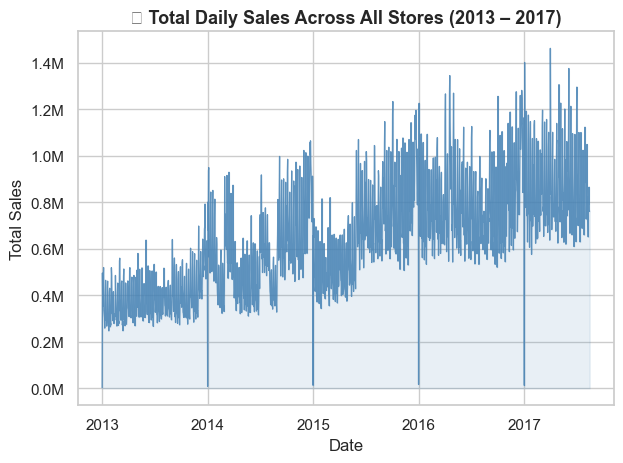

In [6]:
#📊 — Exploratory Data Analysis (EDA)

daily_sales = train_df.groupby('date')['sales'].sum().reset_index()

plt.Figure(figsize=(15, 4))
plt.plot(daily_sales['date'],daily_sales['sales'],
         color='steelblue', linewidth=0.9, alpha=0.85)
plt.fill_between(daily_sales['date'],daily_sales['sales'],
                 alpha =0.12, color='steelblue')
plt.title('📈 Total Daily Sales Across All Stores (2013 – 2017)',
          fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
os.makedirs('data/processed', exist_ok=True)
plt.savefig('data/processed/daily_sales_trend.png', dpi=100, bbox_inches='tight')
plt.show()

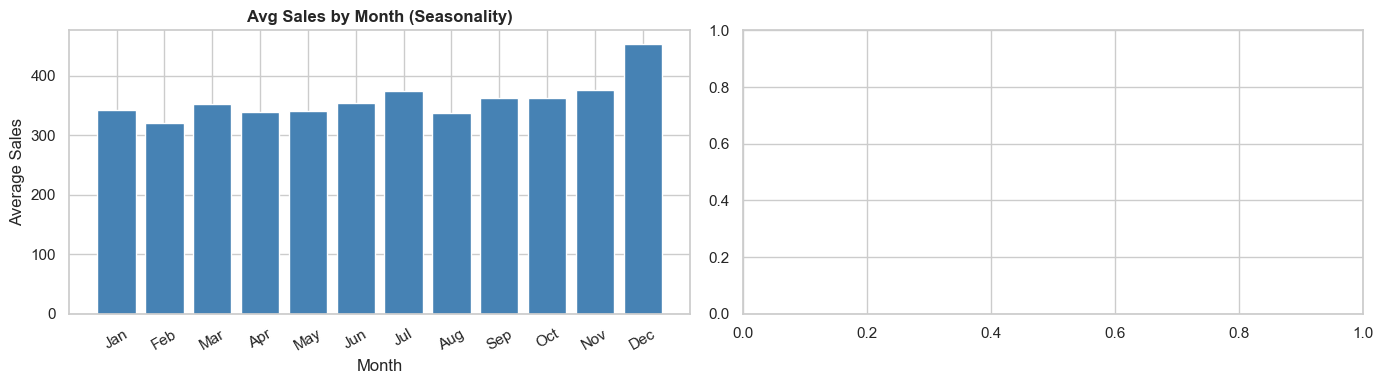

In [7]:
#  Monthly Seasonality
train_df['month'] = train_df['date'].dt.month
train_df['year'] = train_df['date'].dt.year
train_df['dayofweek'] = train_df['date'].dt.dayofweek

monthly_avg = train_df.groupby('month')['sales'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['month_name'] = monthly_avg['month'].apply(lambda x: month_names[x-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly pattern
axes[0].bar(monthly_avg['month_name'],monthly_avg['sales'],
            color ='steelblue', edgecolor = 'white')
axes[0].set_title('Avg Sales by Month (Seasonality)', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Sales')
axes[0].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('data/processed/seasonality_patterns.png', dpi=100, bbox_inches='tight')
plt.show()

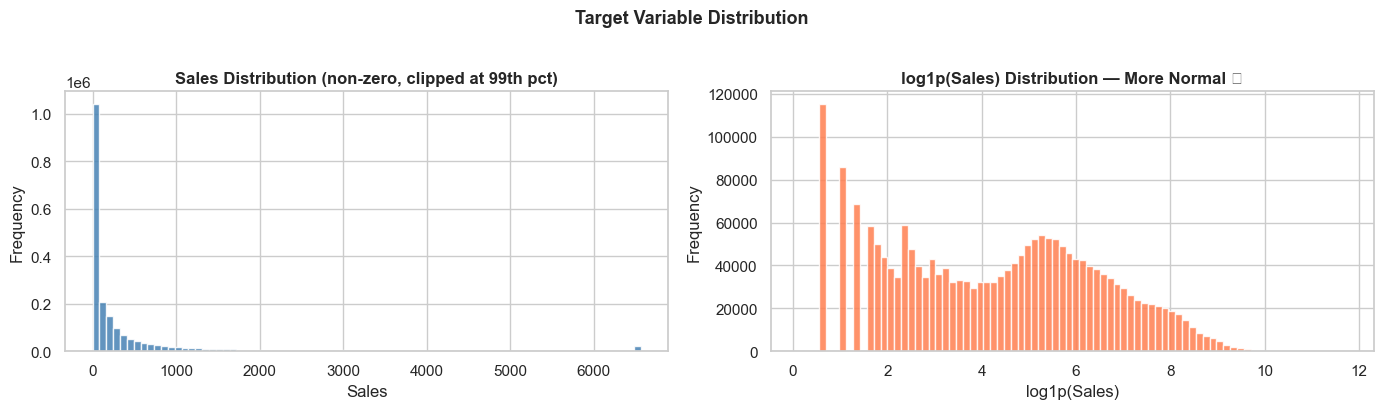

In [8]:
# — Sales Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution (excluding zeros for clarity)
nonzero = train_df[train_df['sales'] > 0]['sales']
axes[0].hist(nonzero.clip(upper=nonzero.quantile(0.99)),
             bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Sales Distribution (non-zero, clipped at 99th pct)',
                  fontweight='bold')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Log-transformed
axes[1].hist(np.log1p(nonzero), bins=80,
             color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('log1p(Sales) Distribution — More Normal ✅',
                  fontweight='bold')
axes[1].set_xlabel('log1p(Sales)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable Distribution', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/processed/sales_distribution.png', dpi=100, bbox_inches='tight')
plt.show()


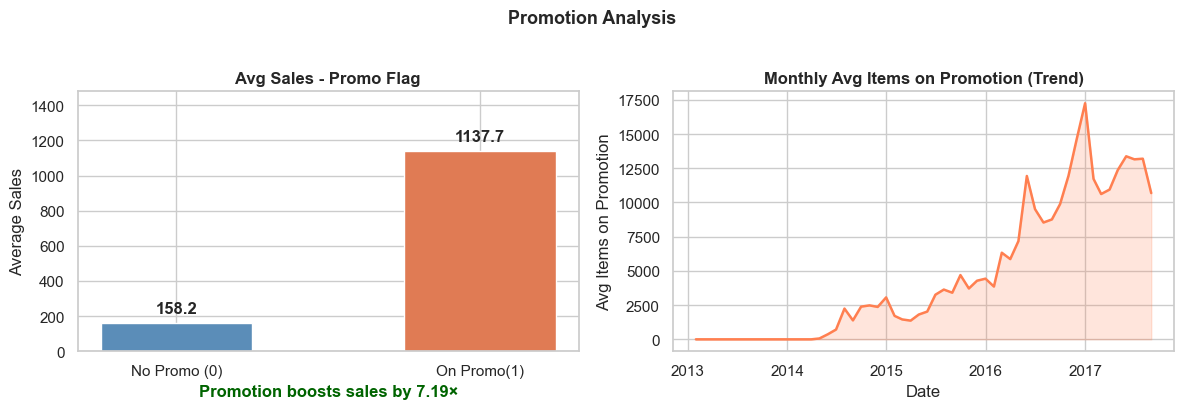

💡 Items on promotion sell 7.19× more on average


In [9]:
# Promotion Impact on Sales

promo_avg = train_df.groupby('onpromotion')['sales'].mean().round()

train_df['promo_flag'] = (train_df['onpromotion'] > 0).astype(int)
promo_flag_avg = train_df.groupby('promo_flag')['sales'].mean().round(2)

fig, axes = plt.subplots(1,2, figsize=(12,4))

bars1 = axes[0].bar(['No Promo (0)', 'On Promo(1)'],
                    promo_flag_avg.values,
                    color=['#5b8db8', '#e07b54'],
                    edgecolor ='white', width=0.5)
axes[0].bar_label(bars1, fmt='%.1f', padding=5, fontweight='bold')
axes[0].set_title('Avg Sales - Promo Flag',  fontweight='bold')
axes[0].set_ylabel('Average Sales')
boost = promo_flag_avg[1] / promo_flag_avg[0]
axes[0].set_xlabel(f'Promotion boosts sales by {boost:.2f}×',
                   color='darkgreen', fontweight='bold')
axes[0].set_ylim(0, promo_flag_avg.max() * 1.3)

# Promo trend over time
promo_trend =(train_df.groupby('date')['onpromotion']
              .sum()
              .resample('ME')
              .mean()
              .reset_index())
axes[1].plot(promo_trend['date'], promo_trend['onpromotion'],
             color='coral', linewidth=1.8)
axes[1].fill_between(promo_trend['date'], promo_trend['onpromotion'],
                     alpha=0.2, color='coral')
axes[1].set_title('Monthly Avg Items on Promotion (Trend)',
                  fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Avg Items on Promotion')

plt.suptitle('Promotion Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/processed/promotion_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'💡 Items on promotion sell {boost:.2f}× more on average')

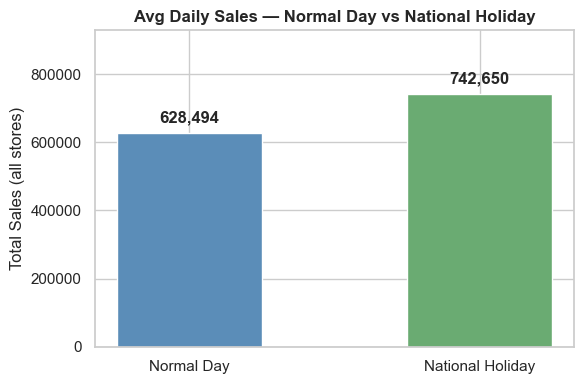

Holiday types found: {'Holiday': 221, 'Event': 56, 'Additional': 51, 'Transfer': 12, 'Bridge': 5, 'Work Day': 5}


In [10]:
# Holiday Impact on Sales

national_hol = hol_df[hol_df['locale'] == 'National'][['date', 'type', 'description']].copy()
national_hol['is_holiday'] = 1

daily_hol = (daily_sales
             .merge(national_hol[['date','is_holiday']], on='date', how='left'))
daily_hol['is_holiday'] = daily_hol['is_holiday'].fillna(0)

hol_avg    = daily_hol.groupby('is_holiday')['sales'].mean().round(0)
hol_labels = ['Normal Day', 'National Holiday']

plt.figure(figsize=(6, 4))
bars = plt.bar(hol_labels, hol_avg.values,
               color=['#5b8db8', '#6aab72'], edgecolor='white', width=0.5)
plt.bar_label(bars,
              labels=[f'{v:,.0f}' for v in hol_avg.values],
              padding=5, fontweight='bold')
plt.title('Avg Daily Sales — Normal Day vs National Holiday',
          fontweight='bold')
plt.ylabel('Total Sales (all stores)')
plt.ylim(0, hol_avg.max() * 1.25)
plt.tight_layout()
plt.savefig('data/processed/holiday_impact.png', dpi=100, bbox_inches='tight')
plt.show()
print('Holiday types found:', hol_df['type'].value_counts().to_dict())

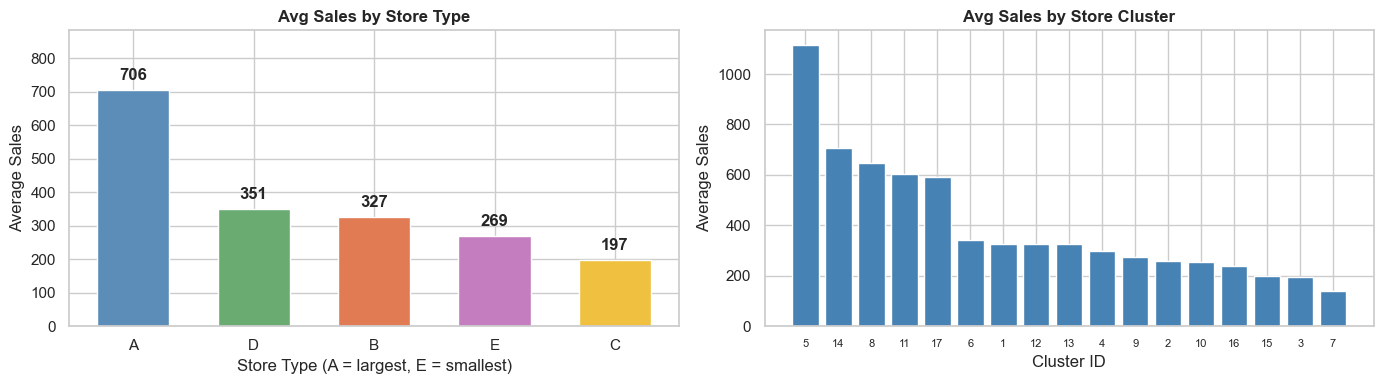

In [11]:
#  — Store Type & Cluster Analysis

train_store = train_df.merge(stores_df, on='store_nbr', how='left')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# By store type
type_avg = (train_store.groupby('type')['sales']
            .mean()
            .sort_values(ascending=False))
colors_t = ['#5b8db8','#6aab72','#e07b54','#c47ec0','#f0c040']
bars1 = axes[0].bar(type_avg.index, type_avg.values,
                    color=colors_t, edgecolor='white', width=0.6)
axes[0].bar_label(bars1, fmt='%.0f', padding=5, fontweight='bold')
axes[0].set_title('Avg Sales by Store Type', fontweight='bold')
axes[0].set_xlabel('Store Type (A = largest, E = smallest)')
axes[0].set_ylabel('Average Sales')
axes[0].set_ylim(0, type_avg.max() * 1.25)

# By cluster
cluster_avg = (train_store.groupby('cluster')['sales']
               .mean()
               .sort_values(ascending=False)
               .reset_index())
axes[1].bar(cluster_avg['cluster'].astype(str), cluster_avg['sales'],
            color='steelblue', edgecolor='white')
axes[1].set_title('Avg Sales by Store Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Average Sales')
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('data/processed/store_type_cluster.png', dpi=100, bbox_inches='tight')
plt.show()

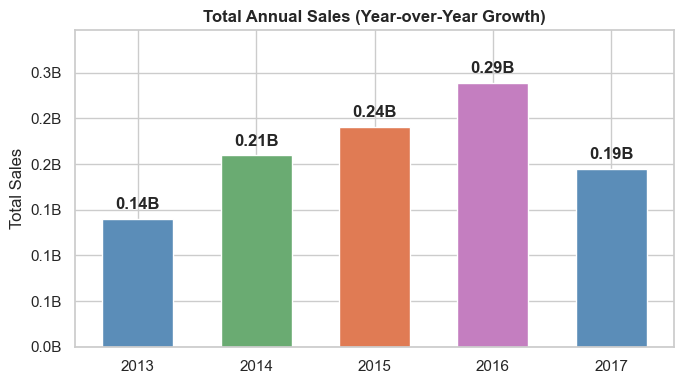

In [12]:
# — Year-over-Year Sales Growth

yearly = train_df.groupby('year')['sales'].sum().reset_index()
yearly = yearly[yearly['year'] < 2027]
plt.figure(figsize=(7, 4))
bars = plt.bar(yearly['year'].astype(str), yearly['sales'],
               color=['#5b8db8','#6aab72','#e07b54','#c47ec0'],
               edgecolor='white', width=0.6)
plt.bar_label(bars,
              labels=[f'{v/1e9:.2f}B' for v in yearly['sales']],
              padding=5, fontweight='bold')
plt.title('Total Annual Sales (Year-over-Year Growth)',
          fontweight='bold')
plt.ylabel('Total Sales')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
plt.ylim(0, yearly['sales'].max() * 1.2)
plt.tight_layout()
plt.savefig('data/processed/yoy_growth.png', dpi=100, bbox_inches='tight')
plt.show()

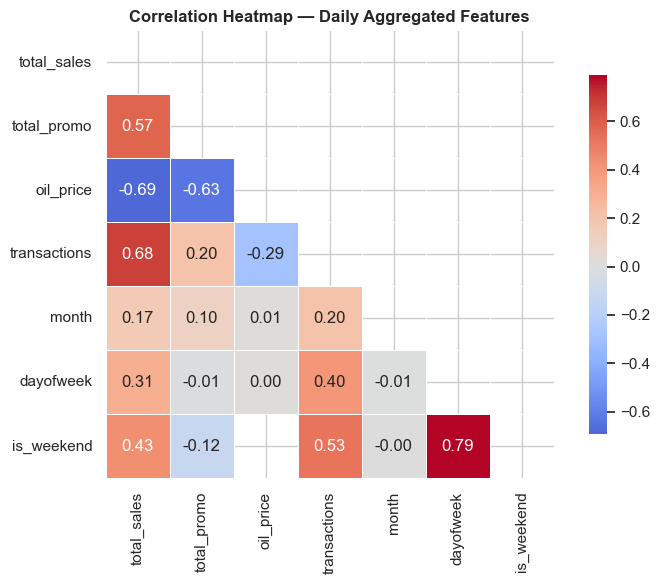

In [13]:
# — Correlation Heatmap

# Build a daily aggregate for correlation analysis
daily_agg = (train_df.groupby('date')
             .agg(total_sales =('sales',sum),
                  total_promo=('onpromotion', 'sum'),
                  promo_items=('promo_flag', 'sum'))
                .reset_index()
                .merge(oil_df.rename(columns={'dcoilwtico':'oil_price'}),
                       on='date',how='left')
                .merge(txn_df.groupby('date')['transactions'].sum().reset_index(),
                    on='date', how='left'))

daily_agg['month']      = daily_agg['date'].dt.month
daily_agg['dayofweek']  = daily_agg['date'].dt.dayofweek
daily_agg['is_weekend'] = (daily_agg['dayofweek'] >= 5).astype(int)

corr_cols = ['total_sales','total_promo','oil_price',
             'transactions','month','dayofweek','is_weekend']
corr = daily_agg[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Daily Aggregated Features',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

Daily Series: 1688 days |2013-01-01 2017-08-15
 Missing dates: 0


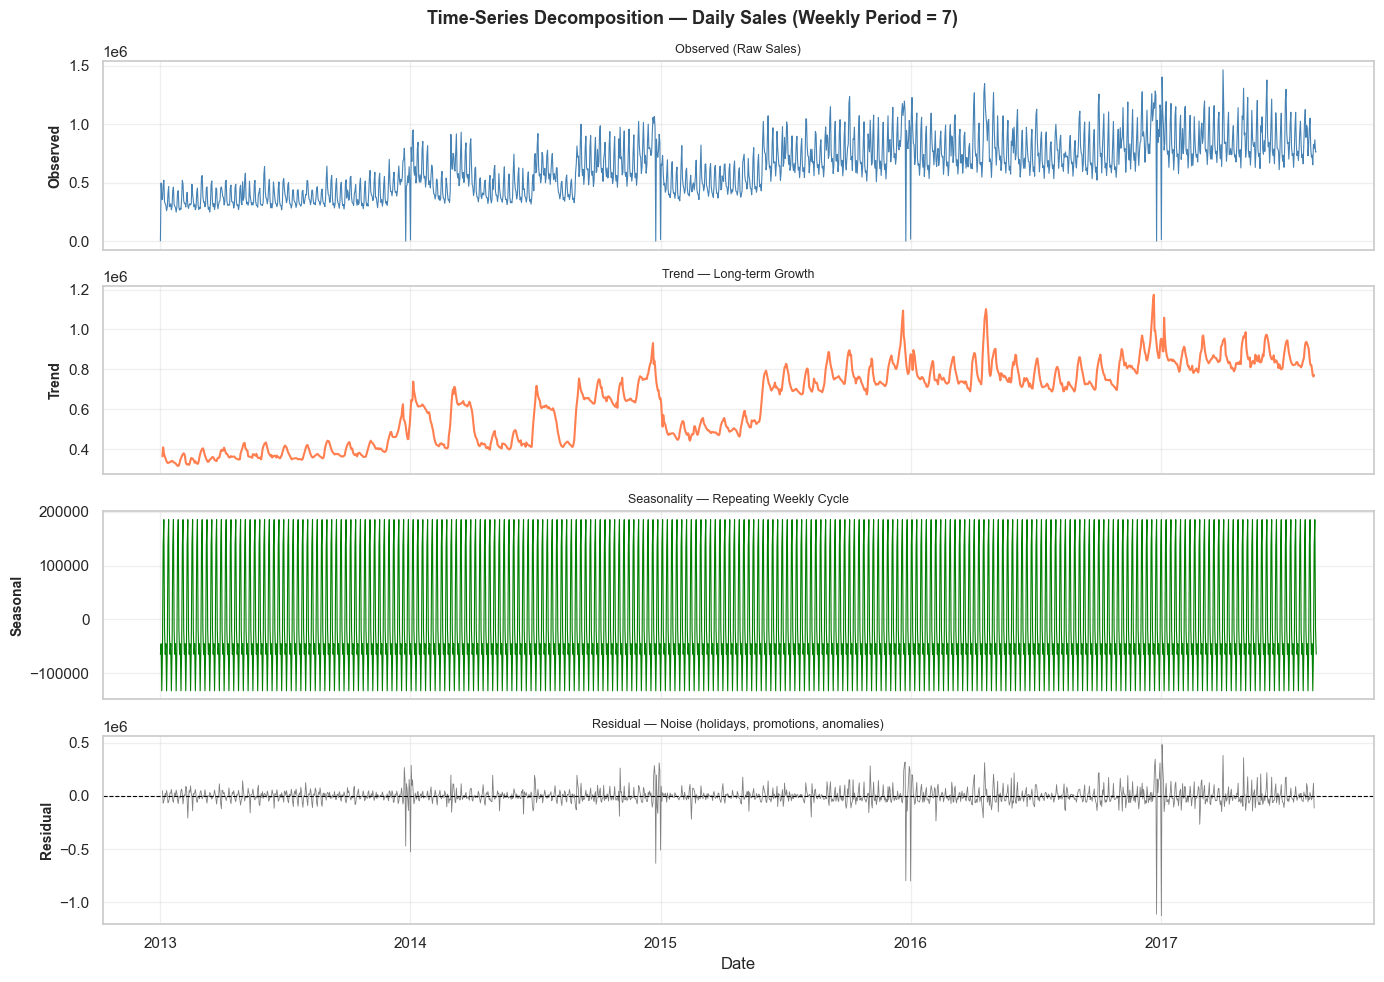


💡 Observation:
   Trend   → Steady upward growth from 2013 to 2017
   Seasonal → Clear weekly cycle — demand repeats every 7 days
   Residual → Large spikes = holidays / promotions not in the weekly pattern


In [14]:
# Time-Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Aggregate train to daily total sales
daily_series = train_df.groupby("date")["sales"].sum()

# Set daily frequency — fill any missing dates with 0
daily_series = daily_series.asfreq("D",fill_value=0)
print(f"Daily Series: {len(daily_series)} days |" 
      f"{daily_series.index.min().date()} {daily_series.index.max().date()}")
print(f" Missing dates: {daily_series.isnull().sum()}")

# Decompose — additive model (trend + seasonal + residual)
result = seasonal_decompose(daily_series, model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Time-Series Decomposition — Daily Sales (Weekly Period = 7)",
             fontsize=13, fontweight="bold")

axes[0].plot(result.observed,  color="steelblue", lw=0.8)
axes[0].set_ylabel("Observed",  fontsize=10, fontweight="bold")
axes[0].set_title("Observed (Raw Sales)", fontsize=9)

axes[1].plot(result.trend,     color="coral",     lw=1.5)
axes[1].set_ylabel("Trend",     fontsize=10, fontweight="bold")
axes[1].set_title("Trend — Long-term Growth", fontsize=9)

axes[2].plot(result.seasonal,  color="green",     lw=0.8)
axes[2].set_ylabel("Seasonal",  fontsize=10, fontweight="bold")
axes[2].set_title("Seasonality — Repeating Weekly Cycle", fontsize=9)

axes[3].plot(result.resid,     color="gray",      lw=0.6)
axes[3].axhline(0, color="black", lw=0.8, linestyle="--")
axes[3].set_ylabel("Residual",  fontsize=10, fontweight="bold")
axes[3].set_title("Residual — Noise (holidays, promotions, anomalies)", fontsize=9)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.savefig("data/processed/time_series_decomposition.png", dpi=100, bbox_inches="tight")
plt.show()

print("")
print("💡 Observation:")
print("   Trend   → Steady upward growth from 2013 to 2017")
print("   Seasonal → Clear weekly cycle — demand repeats every 7 days")
print("   Residual → Large spikes = holidays / promotions not in the weekly pattern")


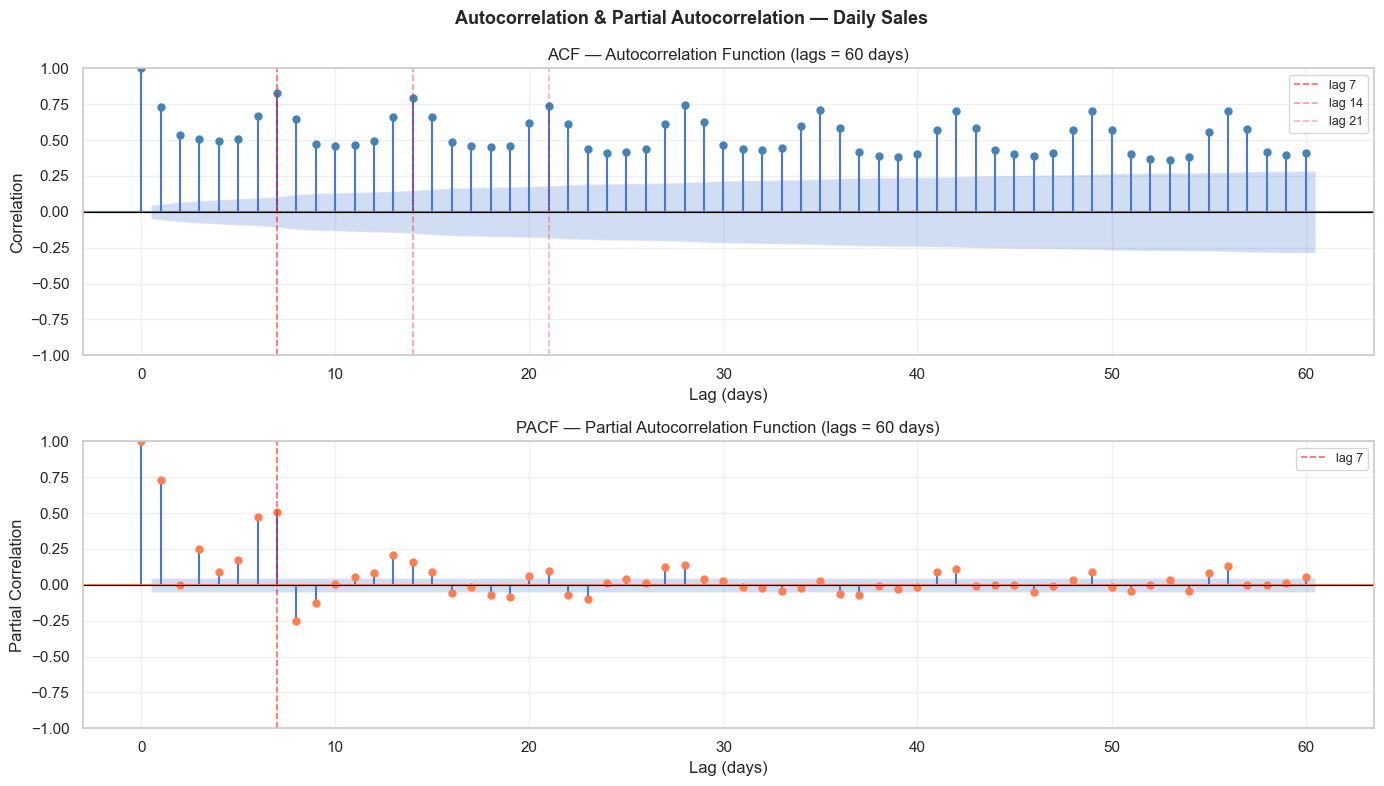

In [15]:
# Autocorrelation Plot (ACF & PACF)

from statsmodels.graphics.tsaplots import plot_acf,plot_pacf


fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Autocorrelation & Partial Autocorrelation — Daily Sales",
             fontsize=13, fontweight="bold")
# --- ACF Plot ---
plot_acf(daily_series, lags=60, ax=axes[0], color="steelblue",
         title="ACF — Autocorrelation Function (lags = 60 days)")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Correlation")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axvline(7,  color="red", lw=1.2, linestyle="--", alpha=0.6, label="lag 7")
axes[0].axvline(14, color="red", lw=1.2, linestyle="--", alpha=0.4, label="lag 14")
axes[0].axvline(21, color="red", lw=1.2, linestyle="--", alpha=0.3, label="lag 21")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- PACF Plot ---
plot_pacf(daily_series, lags=60, ax=axes[1], color="coral",
          title="PACF — Partial Autocorrelation Function (lags = 60 days)")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Partial Correlation")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axvline(7,  color="red", lw=1.2, linestyle="--", alpha=0.6, label="lag 7")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/acf_pacf.png", dpi=100, bbox_inches="tight")
plt.show()


In [16]:
#  Merge All Files into Master DataFrame

# National holiday flag

nat_hol = ( hol_df[hol_df['locale'] == 'National'][['date']]
           .drop_duplicates()
           .assign(is_national_holiday=1))

# Build Master DataFrame
master = (
    train_df
    .merge(stores_df,  on='store_nbr',           how='left')   # store metadata
    .merge(oil_df,     on='date',                how='left')   # oil price
    .merge(txn_df,     on=['date','store_nbr'],  how='left')   # transactions
    .merge(nat_hol,    on='date',                how='left')   # holiday flag
)

# Fill holiday flag 0 where not a holiday

master['is_national_holiday'] = master['is_national_holiday'].fillna(0).astype(int)

# Rename oil column
master.rename(columns={'dcoilwtico': 'oil_price'}, inplace=True)

# date features
master['year']        = master['date'].dt.year
master['month']       = master['date'].dt.month
master['day']         = master['date'].dt.day
master['dayofweek']   = master['date'].dt.dayofweek   # 0=Mon, 6=Sun
master['is_weekend']  = (master['dayofweek'] >= 5).astype(int)
master['promo_flag']  = (master['onpromotion'] > 0).astype(int)

print(f'✅ Master DataFrame shape: {master.shape[0]:,} rows × {master.shape[1]} columns')
print(f'   Columns: {list(master.columns)}')
print(f'\nMissing values in master:')
print(master.isnull().sum()[master.isnull().sum() > 0])
display(master.head())

    

✅ Master DataFrame shape: 3,000,888 rows × 19 columns
   Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'month', 'year', 'dayofweek', 'promo_flag', 'city', 'state', 'type', 'cluster', 'oil_price', 'transactions', 'is_national_holiday', 'day', 'is_weekend']

Missing values in master:
oil_price       858924
transactions    245784
dtype: int64


,id,date,store_nbr,family,sales,onpromotion,month,year,dayofweek,promo_flag,city,state,type,cluster,oil_price,transactions,is_national_holiday,day,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,2013,1,0,Quito,Pichincha,D,13,NaN,NaN,1,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,1,2013,1,0,Quito,Pichincha,D,13,NaN,NaN,1,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,1,2013,1,0,Quito,Pichincha,D,13,NaN,NaN,1,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,2013,1,0,Quito,Pichincha,D,13,NaN,NaN,1,1,0
4,4,2013-01-01,1,BOOKS,0.0,0,1,2013,1,0,Quito,Pichincha,D,13,NaN,NaN,1,1,0


In [17]:
# ✂️Train / Validation / Test Split

TRAIN_END = '2016-12-31'
VAL_END   = '2017-05-31'


df_train = master[master['date'] <= TRAIN_END].copy()
df_val   = master[(master['date'] > TRAIN_END) & (master['date'] <= VAL_END)].copy()
df_test  = master[master['date'] > VAL_END].copy()

total = len(master)
print('✅ Sequential Split Complete')
print('=' * 56)
print(f"  {'Split':<12} {'Date Range':<28} {'Rows':>8}  {'%':>6}")
print('-' * 56)
print(f"  {'Train':<12} {'2013-01-01  →  2016-12-31':<28} {len(df_train):>8,}  {len(df_train)/total*100:>5.1f}%")
print(f"  {'Validation':<12} {'2017-01-01  →  2017-05-31':<28} {len(df_val):>8,}  {len(df_val)/total*100:>5.1f}%")
print(f"  {'Test':<12} {'2017-06-01  →  2017-08-15':<28} {len(df_test):>8,}  {len(df_test)/total*100:>5.1f}%")
print('=' * 56)
print(f"  {'Total':<12} {'':28} {total:>8,}  100.0%")

✅ Sequential Split Complete
  Split        Date Range                       Rows       %
--------------------------------------------------------
  Train        2013-01-01  →  2016-12-31    2,596,374   86.5%
  Validation   2017-01-01  →  2017-05-31     269,082    9.0%
  Test         2017-06-01  →  2017-08-15     135,432    4.5%
  Total                                     3,000,888  100.0%


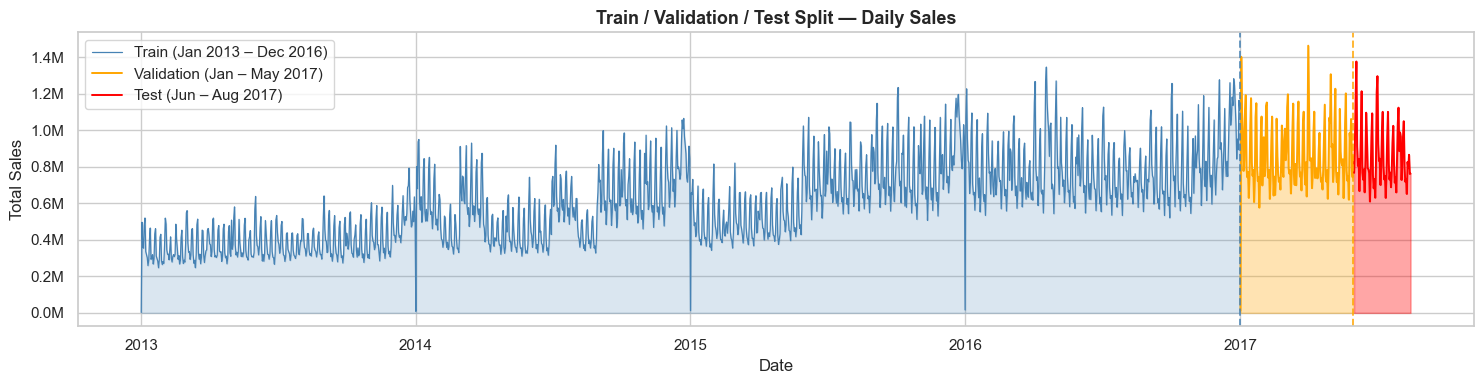

In [18]:
# Visualise the split on the daily sales chart
daily_sales = master.groupby('date')['sales'].sum().reset_index()

train_d = daily_sales[daily_sales['date'] <= TRAIN_END]
val_d   = daily_sales[(daily_sales['date'] > TRAIN_END) & (daily_sales['date'] <= VAL_END)]
test_d  = daily_sales[daily_sales['date'] > VAL_END]

plt.figure(figsize=(15, 4))

plt.fill_between(train_d['date'], train_d['sales'],
                 alpha=0.20, color='steelblue')
plt.plot(train_d['date'], train_d['sales'],
         color='steelblue', linewidth=0.9, label='Train (Jan 2013 – Dec 2016)')

plt.fill_between(val_d['date'], val_d['sales'],
                 alpha=0.30, color='orange')
plt.plot(val_d['date'], val_d['sales'],
         color='orange', linewidth=1.4, label='Validation (Jan – May 2017)')

plt.fill_between(test_d['date'], test_d['sales'],
                 alpha=0.35, color='red')
plt.plot(test_d['date'], test_d['sales'],
         color='red', linewidth=1.4, label='Test (Jun – Aug 2017)')

plt.axvline(pd.Timestamp(TRAIN_END), color='steelblue',
            linestyle='--', linewidth=1.4, alpha=0.8)
plt.axvline(pd.Timestamp(VAL_END), color='orange',
            linestyle='--', linewidth=1.4, alpha=0.8)

plt.title('Train / Validation / Test Split — Daily Sales',
          fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('data/processed/train_val_test_split.png', dpi=100, bbox_inches='tight')
plt.show()

In [19]:
# Sales statistics per split — verify no distribution shift
stats = pd.DataFrame({
    'Split'  : ['Train', 'Validation', 'Test'],
    'Rows'   : [len(df_train), len(df_val), len(df_test)],
    'Mean'   : [df_train['sales'].mean(), df_val['sales'].mean(), df_test['sales'].mean()],
    'Std'    : [df_train['sales'].std(),  df_val['sales'].std(),  df_test['sales'].std()],
    'Min'    : [df_train['sales'].min(),  df_val['sales'].min(),  df_test['sales'].min()],
    'Max'    : [df_train['sales'].max(),  df_val['sales'].max(),  df_test['sales'].max()],
    'Zero %' : [f"{(df_train['sales']==0).mean()*100:.1f}%",
                f"{(df_val['sales']==0).mean()*100:.1f}%",
                f"{(df_test['sales']==0).mean()*100:.1f}%"],
}).round(2)

print('Sales statistics per split:')
display(stats)
print('\n✅ Distribution is consistent across splits — safe to proceed to modelling')

Sales statistics per split:


,Split,Rows,Mean,Std,Min,Max,Zero %
0,Train,2596374,338.71,1055.83,0.0,124717.00,33.8%
1,Validation,269082,479.74,1366.40,0.0,38422.62,15.4%
2,Test,135432,480.89,1332.65,0.0,24744.00,14.4%



✅ Distribution is consistent across splits — safe to proceed to modelling


In [20]:
os.makedirs('data/processed', exist_ok=True)

master.to_csv('data/processed/master_df.csv',       index=False)
df_train.to_csv('data/processed/train_split.csv',   index=False)
df_val.to_csv('data/processed/val_split.csv',       index=False)
df_test.to_csv('data/processed/test_split.csv',     index=False)

print('✅ All files saved to data/processed/')
print()
print('  master_df.csv    — full merged dataset  :', f'{len(master):,} rows')
print('  train_split.csv  — 2013-01-01 → 2016-12-31 :', f'{len(df_train):,} rows')
print('  val_split.csv    — 2017-01-01 → 2017-05-31 :', f'{len(df_val):,} rows')
print('  test_split.csv   — 2017-06-01 → 2017-08-15 :', f'{len(df_test):,} rows')

✅ All files saved to data/processed/

  master_df.csv    — full merged dataset  : 3,000,888 rows
  train_split.csv  — 2013-01-01 → 2016-12-31 : 2,596,374 rows
  val_split.csv    — 2017-01-01 → 2017-05-31 : 269,082 rows
  test_split.csv   — 2017-06-01 → 2017-08-15 : 135,432 rows


# Week 2 — Advanced Feature Engineering

In [21]:
# 1. Setup and Data Loading

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# =========================================================
# YOUR DATASET FOLDER PATH
# =========================================================
raw_dir = Path(r"C:\Users\Prarthana\Desktop\Food_Resturant\Files")

# =========================================================
# FILE PATHS
# =========================================================
paths = {
    'train' : raw_dir / 'train.csv',
    'test'  : raw_dir / 'test.csv',
    'stores': raw_dir / 'stores.csv',
    'oil'   : raw_dir / 'oil.csv',
    'holidays': raw_dir / 'holidays_events.csv',
    'transactions': raw_dir / 'transactions.csv',
    'sample_submission': raw_dir / 'sample_submission.csv',
}

# =========================================================
# CHECK FILES EXIST
# =========================================================
for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path}')

# =========================================================
# LOAD DATASETS
# =========================================================
train_df = pd.read_csv(paths['train'])
test_df = pd.read_csv(paths['test'])
stores_df = pd.read_csv(paths['stores'])
oil_df = pd.read_csv(paths['oil'])
hol_df = pd.read_csv(paths['holidays'])
txn_df = pd.read_csv(paths['transactions'])
sample_submission = pd.read_csv(paths['sample_submission'])

# =========================================================
# CONVERT DATE COLUMNS
# =========================================================
for df, col in [
    (train_df, 'date'),
    (test_df, 'date'),
    (oil_df, 'date'),
    (hol_df, 'date'),
    (txn_df, 'date')
]:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# =========================================================
# DATASET SHAPES
# =========================================================
print("Loaded datasets:")
print("Train Shape         :", train_df.shape)
print("Test Shape          :", test_df.shape)
print("Stores Shape        :", stores_df.shape)
print("Oil Shape           :", oil_df.shape)
print("Holidays Shape      :", hol_df.shape)
print("Transactions Shape  :", txn_df.shape)

Loaded datasets:
Train Shape         : (3000888, 6)
Test Shape          : (28512, 5)
Stores Shape        : (54, 5)
Oil Shape           : (1218, 2)
Holidays Shape      : (350, 6)
Transactions Shape  : (83488, 3)


In [22]:
# 2. Create a Daily Forecasting Dataset

daily_sales = (
    train_df.groupby('date')['sales']
    .sum()
    .reset_index()
    .rename(columns={'sales': 'total_sales'})
)

daily_promo = (
    train_df.groupby('date')['onpromotion']
    .sum()
    .reset_index()
    .rename(columns={'onpromotion': 'total_promo_items'})
)

daily_txn = (
    txn_df.groupby('date')['transactions']
    .sum()
    .reset_index()
)

daily = (
    daily_sales
    .merge(daily_promo, on='date', how='left')
    .merge(daily_txn, on='date', how='left')
    .merge(oil_df.rename(columns={'dcoilwtico': 'oil_price'}), on='date', how='left')
)

daily = daily.sort_values('date').reset_index(drop=True)

# Fill continuous daily dates and interpolate support columns
calendar = pd.DataFrame({'date': pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')})
daily = calendar.merge(daily, on='date', how='left')
daily['total_sales'] = daily['total_sales'].fillna(0)
daily['total_promo_items'] = daily['total_promo_items'].fillna(0)
daily['transactions'] = daily['transactions'].interpolate(method='linear')
daily['oil_price'] = daily['oil_price'].interpolate(method='linear')

daily['is_missing_sales'] = daily['total_sales'].isna().astype(int)
daily['missing_sales'] = daily['total_sales'].isnull().sum()

print('Daily aggregation complete: rows =', len(daily))
daily.head()

Daily aggregation complete: rows = 1688


,date,total_sales,total_promo_items,transactions,oil_price,is_missing_sales,missing_sales
0,2013-01-01,2511.618999,0.0,770.0,NaN,0,0
1,2013-01-02,496092.417944,0.0,93215.0,93.140000,0,0
2,2013-01-03,361461.231124,0.0,78504.0,92.970000,0,0
3,2013-01-04,354459.677093,0.0,78494.0,93.120000,0,0
4,2013-01-05,477350.121229,0.0,93573.0,93.146667,0,0


In [23]:
#  3. Date Features and Holiday Indicators

daily['year'] = daily['date'].dt.year
daily['month'] = daily['date'].dt.month
daily['day'] = daily['date'].dt.day
daily['dayofweek'] = daily['date'].dt.dayofweek
daily['weekofyear'] = daily['date'].dt.isocalendar().week.astype(int)
daily['quarter'] = daily['date'].dt.quarter
daily['is_weekend'] = (daily['dayofweek'] >= 5).astype(int)
daily['is_month_start'] = daily['date'].dt.is_month_start.astype(int)
daily['is_month_end'] = daily['date'].dt.is_month_end.astype(int)

holiday_flags = (
    hol_df[['date', 'type', 'locale', 'description']]
    .copy()
    .assign(is_holiday=1)
)

holiday_flags['holiday_level'] = holiday_flags['locale'].map({
    'National': 3,
    'Regional': 2,
    'Local': 1,
}).fillna(0).astype(int)

daily = daily.merge(holiday_flags[['date', 'is_holiday', 'holiday_level']], on='date', how='left')
daily['is_holiday'] = daily['is_holiday'].fillna(0).astype(int)
daily['holiday_level'] = daily['holiday_level'].fillna(0).astype(int)

print('Holiday flags created:', daily['is_holiday'].sum(), 'holiday rows')
daily[['date','is_holiday','holiday_level']].head(8)

Holiday flags created: 286 holiday rows


,date,is_holiday,holiday_level
0,2013-01-01,1,3
1,2013-01-02,0,0
2,2013-01-03,0,0
3,2013-01-04,0,0
4,2013-01-05,1,3
5,2013-01-06,0,0
6,2013-01-07,0,0
7,2013-01-08,0,0


In [24]:
# 4. Lag Features and Rolling Statistics

lags = [7, 14, 28]
for lag in lags:
    daily[f'sales_lag_{lag}'] = daily['total_sales'].shift(lag)

daily['rolling_mean_7'] = daily['total_sales'].shift(1).rolling(7, min_periods=1).mean()
daily['rolling_std_14'] = daily['total_sales'].shift(1).rolling(14, min_periods=1).std().fillna(0)
daily['rolling_max_7'] = daily['total_sales'].shift(1).rolling(7, min_periods=1).max()
daily['promo_lag_7'] = daily['total_promo_items'].shift(7)
daily['promo_rolling_7'] = daily['total_promo_items'].shift(1).rolling(7, min_periods=1).mean()

daily['sales_log1p'] = np.log1p(daily['total_sales'])

feature_columns = [
    'date', 'total_sales', 'sales_log1p', 'total_promo_items', 'transactions', 'oil_price',
    'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter', 'is_weekend',
    'is_month_start', 'is_month_end', 'is_holiday', 'holiday_level',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'rolling_mean_7', 'rolling_std_14', 'rolling_max_7',
    'promo_lag_7', 'promo_rolling_7'
]

daily_features = daily[feature_columns].copy()
daily_features = daily_features.dropna().reset_index(drop=True)

print('Feature dataset shape after lag feature dropna:', daily_features.shape)
daily_features.head()

Feature dataset shape after lag feature dropna: (1690, 25)


,date,total_sales,sales_log1p,total_promo_items,transactions,oil_price,year,month,day,dayofweek,...,is_holiday,holiday_level,sales_lag_7,sales_lag_14,sales_lag_28,rolling_mean_7,rolling_std_14,rolling_max_7,promo_lag_7,promo_rolling_7
0,2013-01-29,264488.818076,12.485558,0.0,68435.0,97.620000,2013,1,29,1,...,0,0,296214.728983,299129.549954,2511.618999,320916.224872,70726.570278,430411.991233,0.0,0.0
1,2013-01-30,281061.127052,12.546331,0.0,70888.0,97.980000,2013,1,30,2,...,0,0,283258.453032,318347.913946,496092.417944,316383.951885,72506.247548,430411.991233,0.0,0.0
2,2013-01-31,271254.217996,12.510815,0.0,70268.0,97.650000,2013,1,31,3,...,0,0,247245.690995,267498.515975,361461.231124,316070.048174,73580.868185,430411.991233,0.0,0.0
3,2013-02-01,369402.055266,12.819644,0.0,78302.0,97.460000,2013,2,1,4,...,0,0,290022.771930,296130.850028,354459.677093,319499.837745,73358.706951,430411.991233,0.0,0.0
4,2013-02-02,518887.462705,13.159444,0.0,97347.0,97.043333,2013,2,2,5,...,0,0,413799.767975,432459.852021,477350.121229,330839.735365,73676.225736,430411.991233,0.0,0.0


Train rows: 1565
Validation rows: 61
Test rows: 64
Train: 2013-01-29 → 2017-04-15 | rows = 1565
Validation: 2017-04-16 → 2017-06-15 | rows = 61
Test: 2017-06-16 → 2017-08-15 | rows = 64


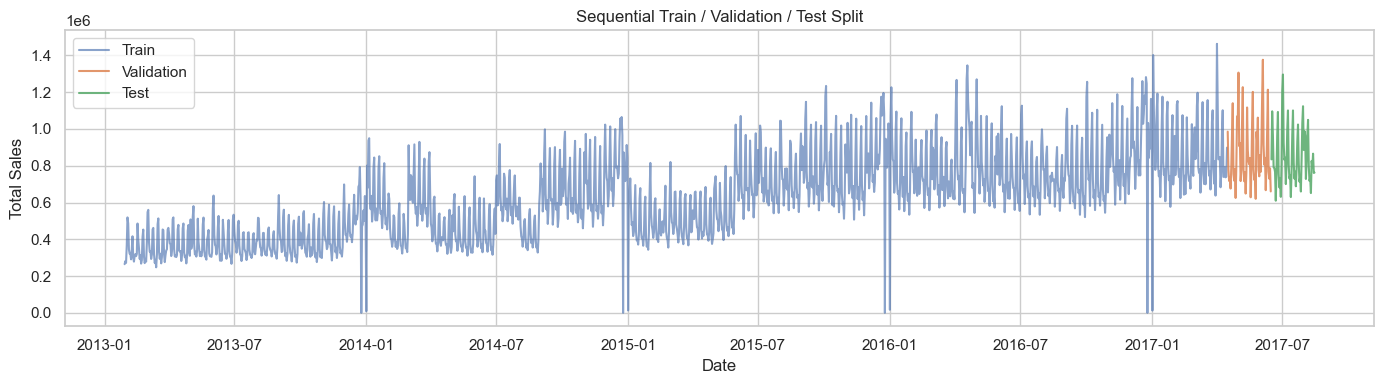

In [25]:
# 5. Sequential Split: Train / Validation / Test

daily_features['date'] = pd.to_datetime(daily_features['date'])

last_day = daily_features['date'].max()

test_start = last_day - pd.DateOffset(months=2) + pd.Timedelta(days=1)
val_start = test_start - pd.DateOffset(months=2)

# =========================================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================================
train_set = daily_features[daily_features['date'] < val_start].copy()

val_set = daily_features[
    (daily_features['date'] >= val_start) &
    (daily_features['date'] < test_start)
].copy()

test_set = daily_features[
    daily_features['date'] >= test_start
].copy()

# =========================================================
# PRINT ROWS
# =========================================================
print('Train rows:', len(train_set))
print('Validation rows:', len(val_set))
print('Test rows:', len(test_set))

# =========================================================
# PRINT DATE RANGE
# =========================================================
for name, df in [('Train', train_set),
                 ('Validation', val_set),
                 ('Test', test_set)]:

    print(f'{name}: {df["date"].min().date()} → {df["date"].max().date()} | rows = {len(df)}')

# =========================================================
# VISUALIZATION
# =========================================================
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train_set['date'],
        train_set['total_sales'],
        label='Train',
        alpha=0.65)

ax.plot(val_set['date'],
        val_set['total_sales'],
        label='Validation',
        alpha=0.85)

ax.plot(test_set['date'],
        test_set['total_sales'],
        label='Test',
        alpha=0.85)

ax.legend()

ax.set_title('Sequential Train / Validation / Test Split')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')

plt.tight_layout()
plt.show()

In [26]:
# 6. Save Processed Feature Dataset

from pathlib import Path

# YOUR SAVE FOLDER PATH
processed_dir = Path(r"C:\Users\Prarthana\Desktop\Food_Resturant\Processed_Files")

# CREATE FOLDER IF NOT EXISTS
processed_dir.mkdir(parents=True, exist_ok=True)

# =========================================================
# SAVE CSV FILES
# =========================================================
daily_features.to_csv(processed_dir / 'week2_features.csv', index=False)

train_set.to_csv(processed_dir / 'train_features.csv', index=False)

val_set.to_csv(processed_dir / 'val_features.csv', index=False)

test_set.to_csv(processed_dir / 'test_features.csv', index=False)

# =========================================================
# PRINT DETAILS
# =========================================================
print('Saved feature datasets to:', processed_dir)

print('week2_features.csv  :', daily_features.shape)

print('train_features.csv  :', train_set.shape)

print('val_features.csv    :', val_set.shape)

print('test_features.csv   :', test_set.shape)

Saved feature datasets to: C:\Users\Prarthana\Desktop\Food_Resturant\Processed_Files
week2_features.csv  : (1690, 25)
train_features.csv  : (1565, 25)
val_features.csv    : (61, 25)
test_features.csv   : (64, 25)


# Week 3: Model Training and Selection 

In [27]:
# 1. Setup and Load Data


import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Direct File Paths ───────────────────────────────────────────────

train_path = r"C:\Users\Prarthana\Desktop\Food_Resturant\Processed_Files\train_features.csv"
val_path   = r"C:\Users\Prarthana\Desktop\Food_Resturant\Processed_Files\val_features.csv"
test_path  = r"C:\Users\Prarthana\Desktop\Food_Resturant\Processed_Files\test_features.csv"

# ── Load CSV Files ──────────────────────────────────────────────────

train_feat = pd.read_csv(train_path, parse_dates=['date'])
val_feat   = pd.read_csv(val_path, parse_dates=['date'])
test_feat  = pd.read_csv(test_path, parse_dates=['date'])

# ── Display Information ─────────────────────────────────────────────

print('Train features :', train_feat.shape)
print('Val   features :', val_feat.shape)
print('Test  features :', test_feat.shape)

print()
print('Columns:', list(train_feat.columns))

Train features : (1565, 25)
Val   features : (61, 25)
Test  features : (64, 25)

Columns: ['date', 'total_sales', 'sales_log1p', 'total_promo_items', 'transactions', 'oil_price', 'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'is_holiday', 'holiday_level', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'rolling_mean_7', 'rolling_std_14', 'rolling_max_7', 'promo_lag_7', 'promo_rolling_7']


In [28]:
# 2. Define Features and Target

# Feature columns — everything except date and the two target columns
FEATURE_COLS = [
    'total_promo_items', 'transactions', 'oil_price',
    'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter',
    'is_weekend', 'is_month_start', 'is_month_end',
    'is_holiday', 'holiday_level',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'rolling_mean_7', 'rolling_std_14', 'rolling_max_7',
    'promo_lag_7', 'promo_rolling_7'
]

TARGET      = 'sales_log1p'   # train on log-scale
TARGET_RAW  = 'total_sales'   # evaluate on raw scale

# Confirm all feature columns are present
missing_cols = [c for c in FEATURE_COLS if c not in train_feat.columns]
if missing_cols:
    raise ValueError(f'Missing feature columns: {missing_cols}')

X_train = train_feat[FEATURE_COLS]
y_train = train_feat[TARGET]
y_train_raw = train_feat[TARGET_RAW]

X_val   = val_feat[FEATURE_COLS]
y_val   = val_feat[TARGET]
y_val_raw = val_feat[TARGET_RAW]

X_test  = test_feat[FEATURE_COLS]
y_test_raw = test_feat[TARGET_RAW]

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}  |  y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}')

X_train: (1565, 22)  |  y_train: (1565,)
X_val  : (61, 22)  |  y_val  : (61,)
X_test : (64, 22)


In [29]:
# 3. Helper — Evaluation Function

def evaluate(model_name: str,
             y_true_raw: pd.Series,
             y_pred_log: np.ndarray) -> dict:
    """
    Convert log-scale predictions back to raw sales, then compute MAE and RMSE.
    Returns a results dict and prints a summary.
    """
    y_pred_raw = np.expm1(y_pred_log)          # inverse of log1p
    y_pred_raw = np.clip(y_pred_raw, 0, None)  # no negative sales

    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))

    print(f'  {model_name:<30}  MAE = {mae:>12,.2f}   RMSE = {rmse:>12,.2f}')
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse,
            'y_pred_raw': y_pred_raw}


results = []   # collect all model results for final comparison


In [30]:
# 4. Baseline — Linear Regression

# Scale features for Linear Regression (tree models don't need this)
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_vl_sc = scaler.transform(X_val)

lr = LinearRegression()
lr.fit(X_tr_sc, y_train)

lr_pred_log = lr.predict(X_vl_sc)

print('── Baseline: Linear Regression ──────────────────────────────')
res_lr = evaluate('Linear Regression', y_val_raw, lr_pred_log)
results.append(res_lr)

── Baseline: Linear Regression ──────────────────────────────
  Linear Regression               MAE =   278,528.20   RMSE =   399,981.67


In [31]:
# 5. Random Forest Regressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred_log = rf.predict(X_val)

print('── Random Forest (default params) ───────────────────────────')
res_rf = evaluate('Random Forest (default)', y_val_raw, rf_pred_log)
results.append(res_rf)

── Random Forest (default params) ───────────────────────────
  Random Forest (default)         MAE =    47,157.61   RMSE =    68,375.39


In [32]:
# 6. XGBoost Regressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred_log = xgb.predict(X_val)

print('── XGBoost (default params) ──────────────────────────────────')
res_xgb = evaluate('XGBoost (default)', y_val_raw, xgb_pred_log)
results.append(res_xgb)

── XGBoost (default params) ──────────────────────────────────
  XGBoost (default)               MAE =    38,234.99   RMSE =    56,071.47


In [33]:
# 7. Hyperparameter Tuning with Time-Series Cross-Validation

# ── Combine train + val for cross-validation ───────────────────────────────
# The test set is never touched here.
X_cv = pd.concat([X_train, X_val], ignore_index=True)
y_cv = pd.concat([y_train, y_val], ignore_index=True)
y_cv_raw = pd.concat([y_train_raw, y_val_raw], ignore_index=True)

tscv = TimeSeriesSplit(n_splits=5)

# Parameter grid to search
param_grid = [
    {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8},
    {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8},
    {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8},
    {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.9},
    {'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.9},
]

print(f'Running {len(param_grid)} parameter sets × {tscv.n_splits} folds ...\n')

cv_results = []

for i, params in enumerate(param_grid):
    fold_maes = []
    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_cv)):
        Xtr, Xvl = X_cv.iloc[tr_idx], X_cv.iloc[vl_idx]
        ytr, yvl = y_cv.iloc[tr_idx], y_cv.iloc[vl_idx]
        yvl_raw  = y_cv_raw.iloc[vl_idx]

        model = XGBRegressor(
            **params,
            colsample_bytree=0.8,
            objective='reg:squarederror',
            n_jobs=-1,
            random_state=42,
            verbosity=0
        )
        model.fit(Xtr, ytr, verbose=False)
        pred_raw = np.expm1(model.predict(Xvl))
        pred_raw = np.clip(pred_raw, 0, None)
        fold_maes.append(mean_absolute_error(yvl_raw, pred_raw))

    mean_mae = np.mean(fold_maes)
    cv_results.append({**params, 'cv_mae': mean_mae})
    print(f'  Params set {i+1}: {params}  →  CV MAE = {mean_mae:,.2f}')

cv_df = pd.DataFrame(cv_results).sort_values('cv_mae')
print('\n── CV Results (sorted by MAE) ──────────────────────────────')
print(cv_df.to_string(index=False))

Running 5 parameter sets × 5 folds ...

  Params set 1: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8}  →  CV MAE = 136,537.42
  Params set 2: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8}  →  CV MAE = 153,275.97
  Params set 3: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8}  →  CV MAE = 146,217.75
  Params set 4: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.9}  →  CV MAE = 139,498.54
  Params set 5: {'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.9}  →  CV MAE = 139,604.48

── CV Results (sorted by MAE) ──────────────────────────────
 n_estimators  max_depth  learning_rate  subsample        cv_mae
          300          4           0.05        0.8 136537.417109
          500          6           0.03        0.9 139498.535689
          700          6           0.03        0.9 139604.479716
          500          6           0.05    

In [34]:
# 8. Train Final Tuned XGBoost on Full Training Data

best_params = cv_df.iloc[0].drop('cv_mae').to_dict()
# n_estimators and max_depth were stored as float by pandas — cast them back
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['max_depth']    = int(best_params['max_depth'])

print('Best hyperparameters:', best_params)

xgb_tuned = XGBRegressor(
    **best_params,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)
xgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_tuned_pred_log = xgb_tuned.predict(X_val)

print('\n── XGBoost (tuned) ────────────────────────────────────────────')
res_xgb_tuned = evaluate('XGBoost (tuned)', y_val_raw, xgb_tuned_pred_log)
results.append(res_xgb_tuned)

Best hyperparameters: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8}

── XGBoost (tuned) ────────────────────────────────────────────
  XGBoost (tuned)                 MAE =    36,873.98   RMSE =    55,965.94


════════════════════════════════════════════════════════════
  MODEL COMPARISON — Validation Set
════════════════════════════════════════════════════════════
                  Model           MAE          RMSE
        XGBoost (tuned)  36873.979267  55965.939241
      XGBoost (default)  38234.986511  56071.466978
Random Forest (default)  47157.608670  68375.386283
      Linear Regression 278528.199595 399981.670431
════════════════════════════════════════════════════════════
  Best model : XGBoost (tuned)
  Best MAE   : 36,873.98
  Best RMSE  : 55,965.94


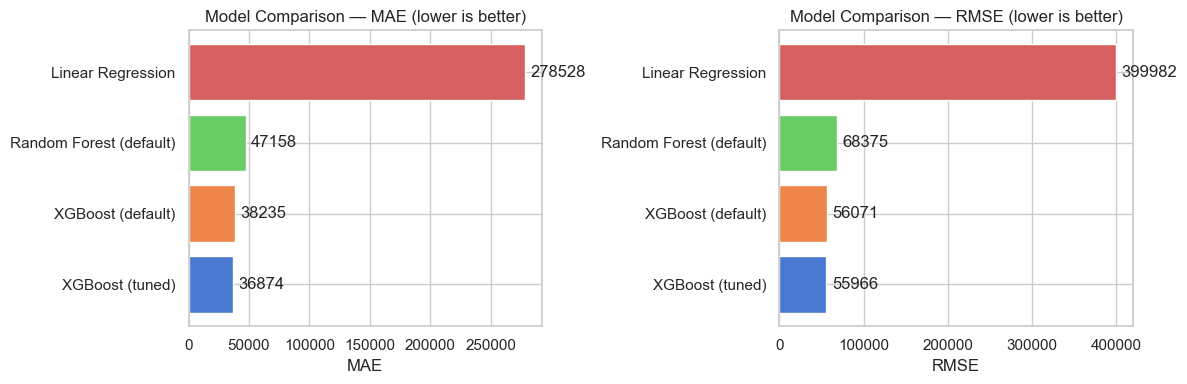

In [35]:
# 9. Model Comparison Summary

summary = pd.DataFrame([{'Model': r['model'], 'MAE': r['MAE'], 'RMSE': r['RMSE']}
                         for r in results])
summary = summary.sort_values('MAE').reset_index(drop=True)

print('═' * 60)
print('  MODEL COMPARISON — Validation Set')
print('═' * 60)
print(summary.to_string(index=False))
print('═' * 60)
print(f'  Best model : {summary.iloc[0]["Model"]}')
print(f'  Best MAE   : {summary.iloc[0]["MAE"]:,.2f}')
print(f'  Best RMSE  : {summary.iloc[0]["RMSE"]:,.2f}')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE']):
    bars = ax.barh(summary['Model'], summary[metric],
                   color=sns.color_palette('muted', len(summary)))
    ax.set_xlabel(metric)
    ax.set_title(f'Model Comparison — {metric} (lower is better)')
    ax.bar_label(bars, fmt='%.0f', padding=4)

plt.tight_layout()
plt.savefig(processed_dir / 'week3_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

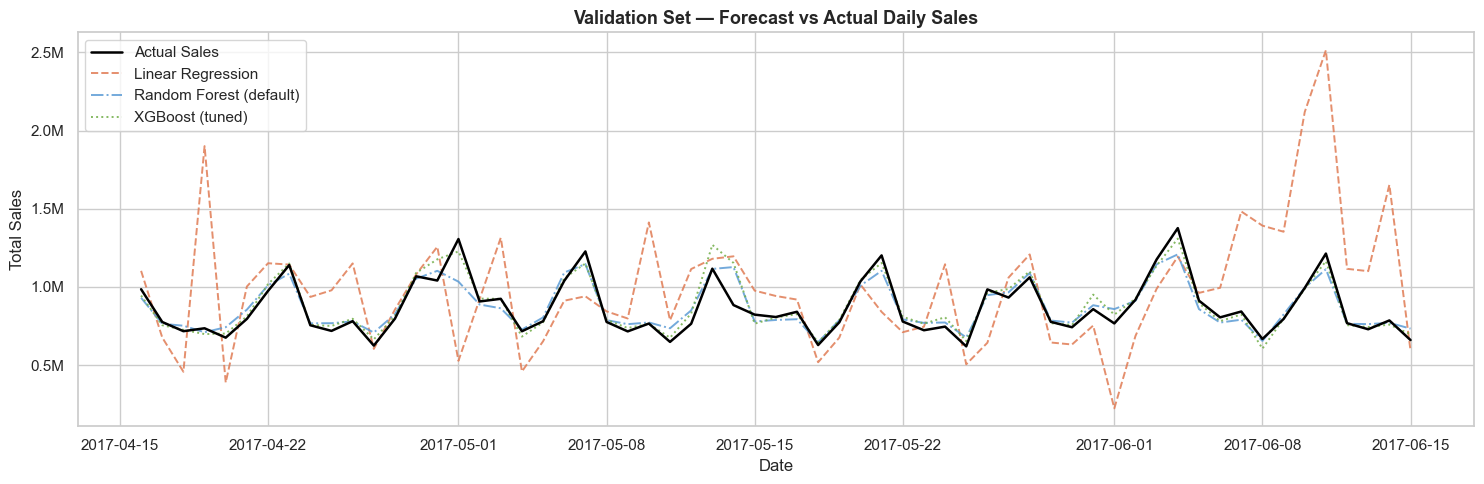

In [36]:
# 10. Forecast vs Actuals — Visual Comparison

val_dates = val_feat['date']

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(val_dates, y_val_raw.values,
        color='black', linewidth=1.8, label='Actual Sales', zorder=5)

colors = ['#e07b54', '#5b9bd5', '#70ad47']
line_styles = ['--', '-.', ':']

for res, color, ls in zip(
        [res_lr, res_rf, res_xgb_tuned],
        colors, line_styles):
    ax.plot(val_dates, res['y_pred_raw'],
            color=color, linewidth=1.4,
            linestyle=ls, alpha=0.85,
            label=res['model'])

ax.set_title('Validation Set — Forecast vs Actual Daily Sales',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(processed_dir / 'week3_forecast_vs_actuals.png', dpi=100, bbox_inches='tight')
plt.show()

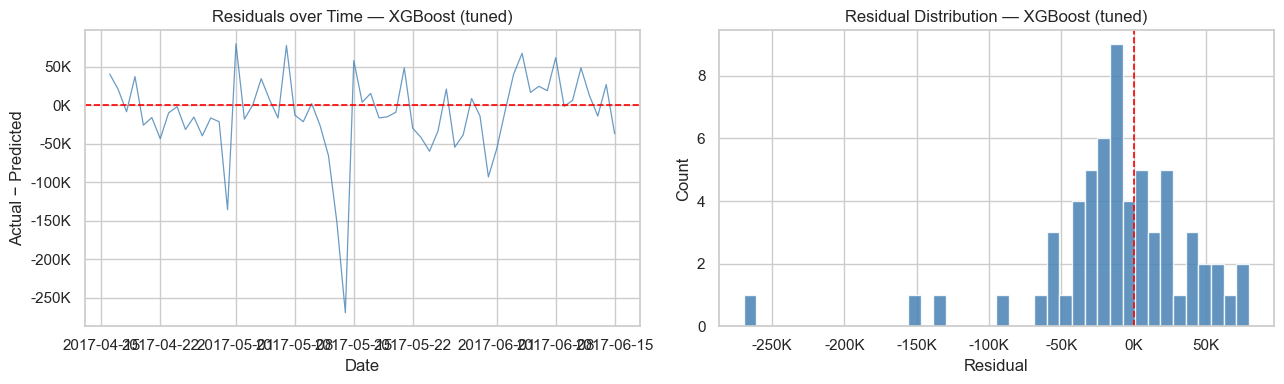

Mean residual  : -11,507.73  (close to 0 = unbiased)
Std of residual: 54,770.05


In [37]:
# 11. Residuals Analysis

best_pred_raw = res_xgb_tuned['y_pred_raw']
residuals     = y_val_raw.values - best_pred_raw

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Residuals over time
axes[0].plot(val_dates, residuals, color='steelblue', linewidth=0.9, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_title('Residuals over Time — XGBoost (tuned)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Actual − Predicted')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Residual distribution
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_title('Residual Distribution — XGBoost (tuned)')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig(processed_dir / 'week3_residuals.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Mean residual  : {residuals.mean():,.2f}  (close to 0 = unbiased)')
print(f'Std of residual: {residuals.std():,.2f}')

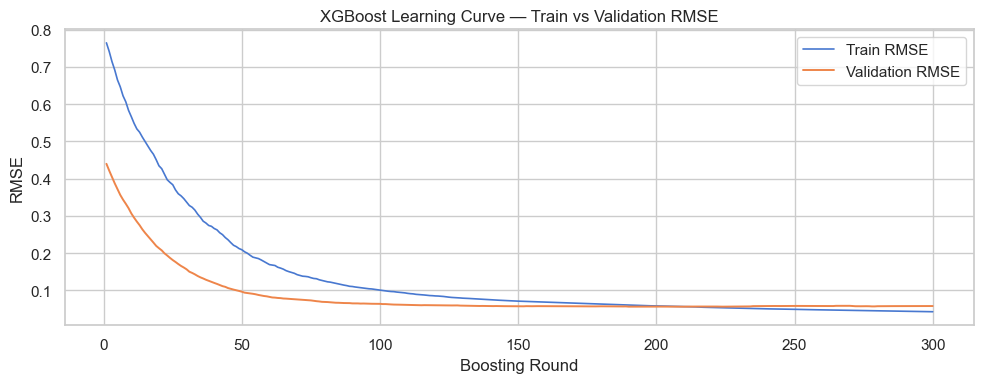

Min val RMSE at round : 210
Min val RMSE value    : 0.05602


In [38]:
# 12. Learning Curve — XGBoost Training vs Validation Loss

# Retrain with eval_metric to capture per-round scores

xgb_lc = XGBRegressor(
    **best_params,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    eval_metric='rmse',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

# Train model
xgb_lc.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Get evaluation results
evals = xgb_lc.evals_result()

train_rmse = evals['validation_0']['rmse']
val_rmse   = evals['validation_1']['rmse']

rounds = range(1, len(train_rmse) + 1)

# Plot learning curve
plt.figure(figsize=(10, 4))

plt.plot(
    rounds,
    train_rmse,
    label='Train RMSE',
    linewidth=1.2
)

plt.plot(
    rounds,
    val_rmse,
    label='Validation RMSE',
    linewidth=1.4
)

plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve — Train vs Validation RMSE')

plt.legend()
plt.tight_layout()

# Save figure
plt.savefig(
    r"C:\Users\Prarthana\Desktop\Food_Resturant\Processed_Files\week3_learning_curve.png",
    dpi=100,
    bbox_inches='tight'
)

plt.show()

# Best validation score
print(f"Min val RMSE at round : {int(np.argmin(val_rmse)) + 1}")
print(f"Min val RMSE value    : {min(val_rmse):.5f}")

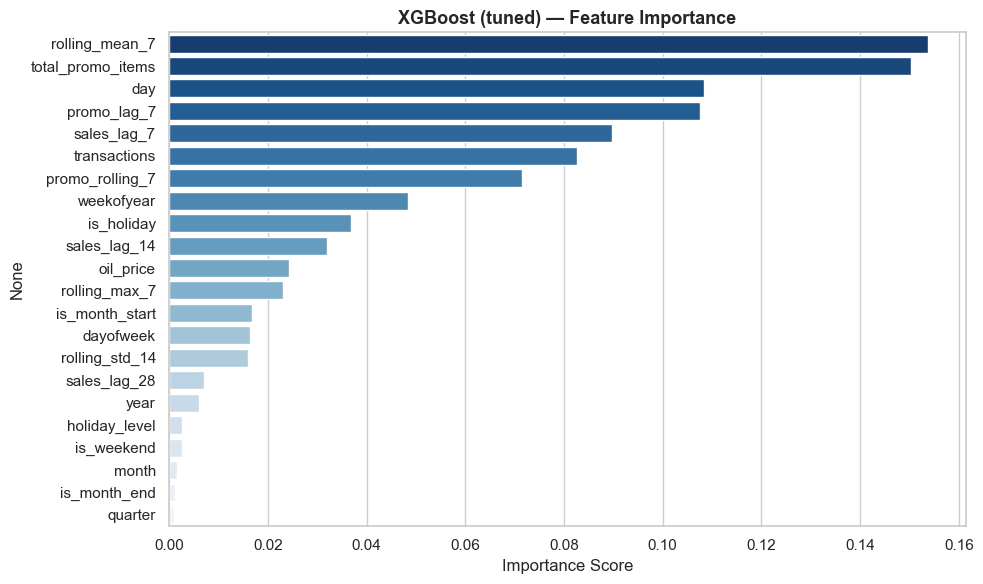


Top 5 most important features:
rolling_mean_7       0.153680
total_promo_items    0.150341
day                  0.108370
promo_lag_7          0.107626
sales_lag_7          0.089739


In [39]:
# 13. Feature Importance

feat_imp = pd.Series(
    xgb_tuned.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=feat_imp.values,
    y=feat_imp.index,
    palette='Blues_r'
)
plt.title('XGBoost (tuned) — Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(processed_dir / 'week3_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(feat_imp.head(5).to_string())

In [40]:
# 14. Save Best Model

model_path  = models_dir / 'xgboost_tuned_week3.pkl'
scaler_path = models_dir / 'scaler_week3.pkl'

joblib.dump(xgb_tuned, model_path)
joblib.dump(scaler,    scaler_path)

print('Model saved to  :', model_path)
print('Scaler saved to :', scaler_path)
print()
print('⚠️  Add models/*.pkl to .gitignore — do not push model weights to GitHub')

NameError: name 'models_dir' is not defined

In [ ]:
# 15. Week 3 Summary

best = summary.iloc[0]

print('═' * 62)
print('  WEEK 3 — FINAL SUMMARY')
print('═' * 62)
print()
print('  Models trained  : Linear Regression, Random Forest, XGBoost')
print('  Tuning method   : TimeSeriesSplit (5 folds), manual grid')
print('  Evaluation set  : Validation set (Jan – May 2017)')
print()
print(f'  Best model      : {best["Model"]}')
print(f'  Best Val MAE    : {best["MAE"]:,.2f}')
print(f'  Best Val RMSE   : {best["RMSE"]:,.2f}')
print()
print('  Outputs saved to data/processed/')
print('    week3_model_comparison.png')
print('    week3_forecast_vs_actuals.png')
print('    week3_residuals.png')
print('    week3_learning_curve.png')
print('    week3_feature_importance.png')
print()
print('  Next step: Week 4 — Final test-set evaluation,')
print('  feature importance business report, forecast dashboard')
print('═' * 62)